In [8]:
import open3d as o3d
import numpy as np
import matplotlib.pyplot as plt
import h5py
import cv2

file_path = r"C:\Users\Pranav Koka\Downloads\nyu_depth_v2_labeled.mat"

# Camera intrinsics for NYU Depth V2 (as provided)
K = np.array([
    [518.8579, 0, 325.5824],
    [0, 519.4696, 253.7362],
    [0, 0, 1]
])

In [9]:
with h5py.File(file_path, "r") as f:
    rgb_images = np.array(f["images"])  # Shape: (N, 3, 640, 480)
    depth_maps = np.array(f["depths"])  # Shape: (N, 640, 480)

print("RGB Images Shape:", rgb_images.shape)
print("Depth Maps Shape:", depth_maps.shape)

RGB Images Shape: (1449, 3, 640, 480)
Depth Maps Shape: (1449, 640, 480)


In [10]:
index = 1  # Select a frame
rgb = rgb_images[index]  # (3, 640, 480)
depth = depth_maps[index]  # (640, 480)
print("RGB Image Shape (Before Resize):", rgb.shape)
print("Depth Map Shape:", depth.shape)

RGB Image Shape (Before Resize): (3, 640, 480)
Depth Map Shape: (640, 480)


In [11]:
# Transpose to (H, W, C)
rgb = np.transpose(rgb, (1, 2, 0))  # Shape is now (640, 480, 3)
print("RGB Image Shape (After Transpose):", rgb.shape)
print("Depth Map Shape:", depth.shape)

print("RGB Data Type:", rgb.dtype)

# Resize RGB to match depth resolution (480, 640)
rgb_resized = cv2.resize(rgb, (depth.shape[1], depth.shape[0]))  # Resizing to (640, 480)

RGB Image Shape (After Transpose): (640, 480, 3)
Depth Map Shape: (640, 480)
RGB Data Type: uint8


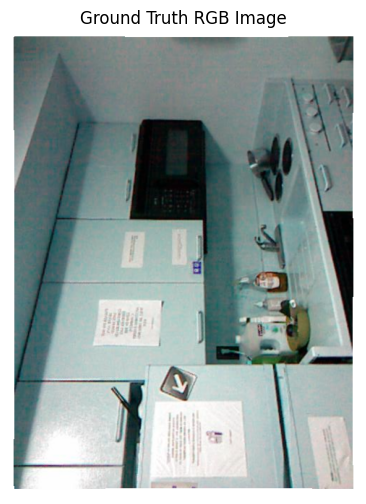

In [12]:
plt.figure(figsize=(8, 6))
plt.imshow(cv2.cvtColor(rgb_resized, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title("Ground Truth RGB Image")
plt.show()

In [13]:
def depth_to_point_cloud(depth, rgb, K):
    """Convert depth map to 3D point cloud using camera intrinsics"""
    h, w = depth.shape
    fx, fy = K[0, 0], K[1, 1]  # Focal lengths
    cx, cy = K[0, 2], K[1, 2]  # Principal point

    # Create a mesh grid of pixel coordinates
    u, v = np.meshgrid(np.arange(w), np.arange(h))

    # Compute normalized camera coordinates
    X = (u - cx) * depth / fx
    Y = (v - cy) * depth / fy
    Z = depth

    # Stack into (N, 3) format
    points = np.stack((X, Y, Z), axis=-1).reshape(-1, 3)
    
    # Get corresponding RGB colors
    colors = rgb.reshape(-1, 3) / 255.0  # Normalize to [0, 1]

    return points, colors

In [14]:
# Generate point cloud
points, colors = depth_to_point_cloud(depth, rgb_resized, K)

# Convert to Open3D format
pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(points)
pcd.colors = o3d.utility.Vector3dVector(colors)

# Visualize the point cloud
o3d.visualization.draw_geometries([pcd], zoom=0.5, front=[0, 0, -1], lookat=[0, 0, 0], up=[0, -1, 0])


The 3d reconstruction above was done using gt rgb, gt depth, and gt k

In [15]:
import torch
from PIL import Image
from depth_pro import depth_pro
from depth_pro.network.decoder import MultiresConvDecoder
from depth_pro.network.encoder import DepthProEncoder
from depth_pro.network.fov import FOVNetwork

checkpoint_path = "C:/Users/Pranav Koka/ml-depth-pro/checkpoints/depth_pro.pt"
config = depth_pro.DepthProConfig(
    checkpoint_uri=checkpoint_path,
    patch_encoder_preset="dinov2l16_384",
    image_encoder_preset="dinov2l16_384",
    decoder_features=256,
    use_fov_head=True,
    fov_encoder_preset="dinov2l16_384"
)
# Load the model state dictionary
model, transform = depth_pro.create_model_and_transforms(config=config)
model.eval()


C:\Users\Pranav Koka\ml-depth-pro\src\depth_pro\depth_pro.py:136: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(config.checkpoint_uri, map_location="

DepthPro(
  (encoder): DepthProEncoder(
    (patch_encoder): VisionTransformer(
      (patch_embed): PatchEmbed(
        (proj): Conv2d(3, 1024, kernel_size=(16, 16), stride=(16, 16))
        (norm): Identity()
      )
      (pos_drop): Dropout(p=0.0, inplace=False)
      (patch_drop): Identity()
      (norm_pre): Identity()
      (blocks): Sequential(
        (0): Block(
          (norm1): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
          (attn): Attention(
            (qkv): Linear(in_features=1024, out_features=3072, bias=True)
            (q_norm): Identity()
            (k_norm): Identity()
            (attn_drop): Dropout(p=0.0, inplace=False)
            (proj): Linear(in_features=1024, out_features=1024, bias=True)
            (proj_drop): Dropout(p=0.0, inplace=False)
          )
          (ls1): LayerScale()
          (drop_path1): Identity()
          (norm2): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
          (mlp): Mlp(
            (fc1): Linea

In [16]:
# Assuming your rgb image is stored as 'rgb' in numpy format
# Convert numpy array to PIL Image if needed
if isinstance(rgb, np.ndarray):
    rgb_image = Image.fromarray(rgb)

# If the image is in PIL format, proceed to transform
image = transform(rgb_image).unsqueeze(0)  # Add batch dimension


In [31]:
rgb.shape

(640, 480, 3)

In [36]:
# Provide the focal length (in pixels) - Modify this based on your data
f_px = torch.tensor([518.8579])  # Replace this with your actual focal length in pixels

# Run inference
with torch.no_grad():
    prediction = model.infer(image, f_px=f_px)
    depth_map = prediction["depth"]  # Depth map in meters
    focal_length_px = prediction["focallength_px"]  # Focal length in pixels

# Convert depth map to numpy array for further processing
depth_map = depth_map.cpu().numpy()

In [41]:
points, colors = depth_to_point_cloud(depth_map, rgb_resized, K)

# Convert to Open3D format
pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(points)
pcd.colors = o3d.utility.Vector3dVector(colors)

# Visualize the point cloud
o3d.visualization.draw_geometries([pcd], zoom=0.5, front=[0, 0, -1], lookat=[0, 0, 0], up=[0, -1, 0])

The 3d reconstruction above was done using gt rgb, pred depth, and gt k

In [ ]:
with torch.no_grad():
    prediction = model.infer(image, f_px=None)  # Setting f_px=None triggers intrinsic prediction
    predicted_f_px = prediction["focallength_px"].item()  # This is the predicted focal length in pixels

print("Predicted Focal Length (in pixels):", predicted_f_px)


Predicted Focal Length (in pixels): 423.8392028808594


In [39]:
rgb.shape

(640, 480, 3)

In [40]:
H, W, _ = rgb.shape

# Use the predicted focal length
f_px = predicted_f_px  # Obtained from the DepthPro model's inference

# Create the intrinsic matrix K
K_pred = np.array([
    [f_px, 0, H / 2],
    [0, f_px, W / 2],
    [0, 0, 1]
])

print("Constructed Intrinsic Matrix K:")
print(K_pred)

Constructed Intrinsic Matrix K:
[[423.83920288   0.         320.        ]
 [  0.         423.83920288 240.        ]
 [  0.           0.           1.        ]]


In [42]:
points, colors = depth_to_point_cloud(depth, rgb_resized, K_pred)

# Convert to Open3D format
pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(points)
pcd.colors = o3d.utility.Vector3dVector(colors)

# Visualize the point cloud
o3d.visualization.draw_geometries([pcd], zoom=0.5, front=[0, 0, -1], lookat=[0, 0, 0], up=[0, -1, 0])

[Open3D WARNING] GLFW Error: WGL: Failed to make context current: The handle is invalid. 


The 3d reconstruction above was done using gt rgb, gt depth, and pred k

In [44]:
with torch.no_grad():
    prediction = model.infer(image, f_px=None)  # Setting f_px=None triggers intrinsic prediction
    depth_map_pred = prediction["depth"].cpu().numpy()
    predicted_f_px = prediction["focallength_px"].item()  # This is the predicted focal length in pixels

print("Predicted Focal Length (in pixels):", predicted_f_px)

H, W, _ = rgb.shape

# Use the predicted focal length
f_px = predicted_f_px  # Obtained from the DepthPro model's inference

# Create the intrinsic matrix K
K_pred = np.array([
    [f_px, 0, H / 2],
    [0, f_px, W / 2],
    [0, 0, 1]
])

print("Constructed Intrinsic Matrix K:")
print(K_pred)

Predicted Focal Length (in pixels): 423.8392028808594
Constructed Intrinsic Matrix K:
[[423.83920288   0.         320.        ]
 [  0.         423.83920288 240.        ]
 [  0.           0.           1.        ]]


In [45]:
points, colors = depth_to_point_cloud(depth_map_pred, rgb_resized, K_pred)

# Convert to Open3D format
pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(points)
pcd.colors = o3d.utility.Vector3dVector(colors)

# Visualize the point cloud
o3d.visualization.draw_geometries([pcd], zoom=0.5, front=[0, 0, -1], lookat=[0, 0, 0], up=[0, -1, 0])

The 3d reconstruction above was done using gt rgb, pred depth, and pred k (both predicted with just the gt rgb)